# Phase 6: Evaluation and Interpretability

In [1]:
# Setting the directories

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

LABEL_ORDER = ['Non-Demented', 'Very Mild Demented', 'Mild Demented', 'Moderate Demented']

_cwd = os.path.abspath(os.getcwd())
BASE_DIR = os.path.dirname(_cwd) if os.path.basename(_cwd) == 'notebooks' else _cwd

PROCESSED_DIR = os.path.join(BASE_DIR, 'data', 'processed')
MODELS_DIR    = os.path.join(BASE_DIR, 'outputs', 'models')
METRICS_DIR   = os.path.join(BASE_DIR, 'outputs', 'metrics')
PLOTS_DIR     = os.path.join(BASE_DIR, 'outputs', 'plots')
PCA_COMP_DIR  = os.path.join(BASE_DIR, 'outputs', 'pca_components')
REPORTS_DIR   = os.path.join(BASE_DIR, 'reports')

In [2]:
# Loading test data and trained models

X_test  = np.load(os.path.join(PROCESSED_DIR, 'X_test.npy'))
y_test  = np.load(os.path.join(PROCESSED_DIR, 'y_test.npy'))
X_pca   = np.load(os.path.join(PROCESSED_DIR, 'X_pca.npy'))
y_all   = np.load(os.path.join(PROCESSED_DIR, 'y.npy'))

with open(os.path.join(MODELS_DIR, 'svm_linear.pkl'), 'rb') as f:
    svm_linear = pickle.load(f)

with open(os.path.join(MODELS_DIR, 'svm_rbf.pkl'), 'rb') as f:
    svm_rbf = pickle.load(f)

print(f'X_test shape : {X_test.shape}')
print(f'y_test shape : {y_test.shape}')
print(f'Test class counts:')
for label in LABEL_ORDER:
    print(f'  {label}: {(y_test == label).sum()}')

X_test shape : (89, 233)
y_test shape : (89,)
Test class counts:
  Non-Demented: 68
  Very Mild Demented: 14
  Mild Demented: 6
  Moderate Demented: 1


In [3]:
# Generating predictions

y_pred_linear = svm_linear.predict(X_test)
y_pred_rbf    = svm_rbf.predict(X_test)

print(f'Linear SVM accuracy : {accuracy_score(y_test, y_pred_linear):.4f}')
print(f'RBF SVM accuracy    : {accuracy_score(y_test, y_pred_rbf):.4f}')

Linear SVM accuracy : 0.6854
RBF SVM accuracy    : 0.7640


In [4]:
# Saving classification report

# Note: Moderate class has only 1 test sample : its per-class metrics are not statistically reliable.
# The confusion matrix is the primary diagnostic for that class.

report_linear = classification_report(y_test, y_pred_linear, zero_division=0)
report_rbf    = classification_report(y_test, y_pred_rbf,    zero_division=0)

print('Linear SVM:')
print(report_linear)
print('RBF SVM:')
print(report_rbf)

best_model = 'Linear' if accuracy_score(y_test, y_pred_linear) >= accuracy_score(y_test, y_pred_rbf) else 'RBF'
best_report = report_linear if best_model == 'Linear' else report_rbf

with open(os.path.join(METRICS_DIR, 'classification_report.txt'), 'w') as f:
    f.write(f'Best model: {best_model} SVM\n')
    f.write('Note: Moderate class has 1 test sample only. Per-class F1 for Moderate is not reliable.\n\n')
    f.write('Linear SVM:\n')
    f.write(report_linear)
    f.write('\nRBF SVM:\n')
    f.write(report_rbf)

Linear SVM:
                    precision    recall  f1-score   support

     Mild Demented       0.00      0.00      0.00         6
 Moderate Demented       0.50      1.00      0.67         1
      Non-Demented       0.81      0.88      0.85        68
Very Mild Demented       0.00      0.00      0.00        14

          accuracy                           0.69        89
         macro avg       0.33      0.47      0.38        89
      weighted avg       0.63      0.69      0.65        89

RBF SVM:
                    precision    recall  f1-score   support

     Mild Demented       0.00      0.00      0.00         6
 Moderate Demented       1.00      1.00      1.00         1
      Non-Demented       0.81      0.96      0.88        68
Very Mild Demented       0.25      0.14      0.18        14

          accuracy                           0.76        89
         macro avg       0.52      0.52      0.52        89
      weighted avg       0.67      0.76      0.71        89



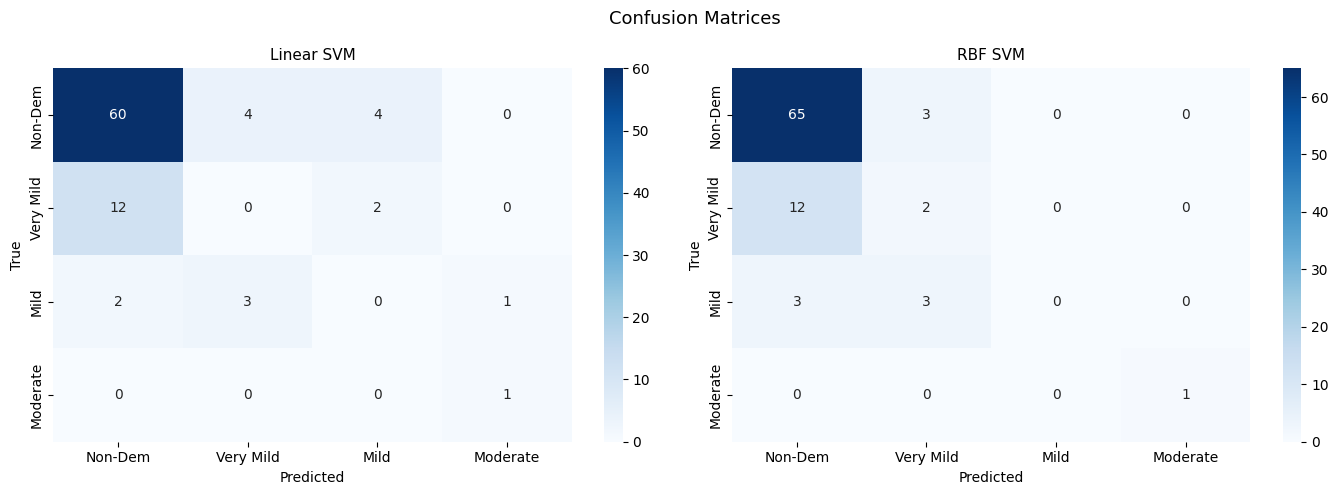

In [5]:
# Plotting confusion matrices

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_linear, y_pred_rbf],
    ['Linear SVM', 'RBF SVM']
):
    cm = confusion_matrix(y_test, y_pred, labels=LABEL_ORDER)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Non-Dem', 'Very Mild', 'Mild', 'Moderate'],
        yticklabels=['Non-Dem', 'Very Mild', 'Mild', 'Moderate']
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle('Confusion Matrices', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

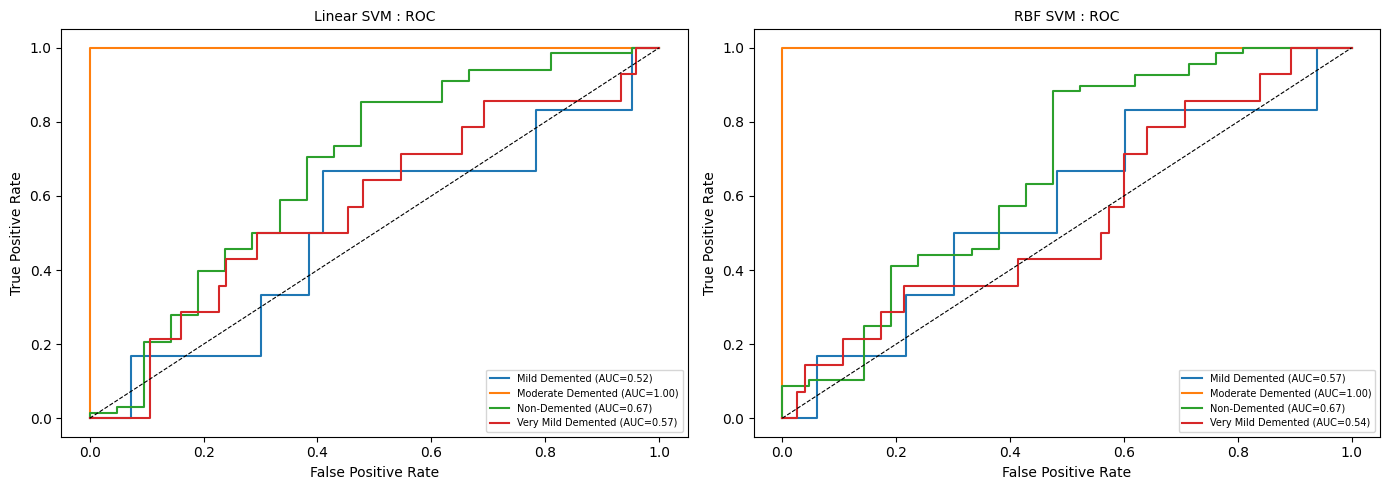

In [6]:
# Plotting ROC curves : one vs rest multiclass

# Binarising using the model internal class order to match predict_proba column order
classes = svm_linear.classes_
y_test_bin = label_binarize(y_test, classes=classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, title in zip(
    axes,
    [svm_linear, svm_rbf],
    ['Linear SVM', 'RBF SVM']
):
    y_score = model.predict_proba(X_test)
    for i, label in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, linewidth=1.5, label=f'{label} (AUC={roc_auc:.2f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    ax.set_title(f'{title} : ROC', fontsize=10)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'roc_curves.png'), dpi=150)
plt.show()

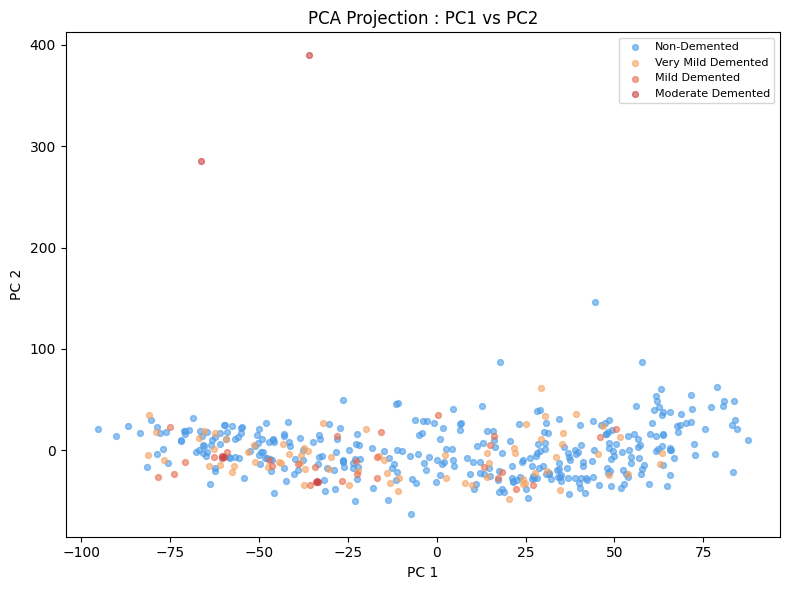

In [7]:
# Plotting PCA projection scatter

colors = {
    'Non-Demented':       '#4C9BE8',
    'Very Mild Demented': '#F4A261',
    'Mild Demented':      '#E76F51',
    'Moderate Demented':  '#C94040'
}

fig, ax = plt.subplots(figsize=(8, 6))

for label in LABEL_ORDER:
    mask = y_all == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               label=label, alpha=0.6, s=18, color=colors[label])

ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_title('PCA Projection : PC1 vs PC2')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'pca_projection.png'), dpi=150)
plt.show()

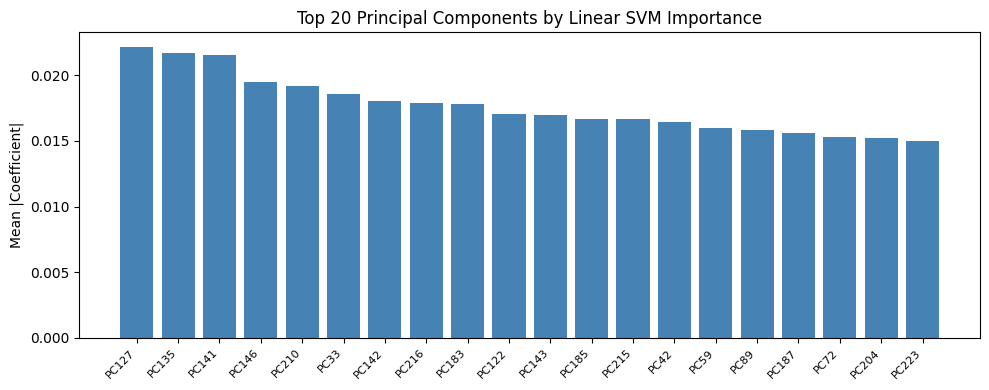

In [8]:
# Visualising component importance from Linear SVM

# Taking mean absolute coefficient across all one-vs-one decision boundaries
coef_abs = np.abs(svm_linear.coef_).mean(axis=0)
top_n = 20
top_idx = np.argsort(coef_abs)[::-1][:top_n]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(top_n), coef_abs[top_idx], color='steelblue')
ax.set_xticks(range(top_n))
ax.set_xticklabels([f'PC{i+1}' for i in top_idx], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Mean |Coefficient|')
ax.set_title(f'Top {top_n} Principal Components by Linear SVM Importance')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'component_importance.png'), dpi=150)
plt.show()

In [9]:
# Saving experiment summary

from sklearn.metrics import f1_score

summary = []
for name, model, y_pred in [
    ('Linear SVM', svm_linear, y_pred_linear),
    ('RBF SVM',    svm_rbf,    y_pred_rbf)
]:
    summary.append({
        'model':       name,
        'accuracy':    round(accuracy_score(y_test, y_pred), 4),
        'f1_macro':    round(f1_score(y_test, y_pred, average='macro',    zero_division=0), 4),
        'f1_weighted': round(f1_score(y_test, y_pred, average='weighted', zero_division=0), 4),
        'best_params': str(model.get_params())
    })

df_summary = pd.DataFrame(summary)
df_summary.to_csv(os.path.join(REPORTS_DIR, 'experiment_summary.csv'), index=False)
print(df_summary.to_string(index=False))

     model  accuracy  f1_macro  f1_weighted                                                                                                                                                                                                                                                                                                                                                                                     best_params
Linear SVM    0.6854    0.3779       0.6532 {'C': 0.1, 'break_ties': False, 'cache_size': 200, 'class_weight': {'Mild Demented': 1.6115, 'Moderate Demented': 3.4917, 'Non-Demented': 0.3909, 'Very Mild Demented': 1.8705}, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'linear', 'max_iter': -1, 'probability': True, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}
   RBF SVM    0.7640    0.5150       0.7110    {'C': 100, 'break_ties': False, 'cache_size': 200, 'class_weight': {'Mild Demented': 1.6115, 'Mod

In [10]:
# Saving experiment configuration

import json

config = {
    'random_seed':            RANDOM_SEED,
    'image_size':             [128, 128],
    'target_slice':           130,
    'slice_selection':        'closest available to target, no range restriction',
    'pca_variance_threshold': 0.95,
    'pca_n_components':       233,
    'train_test_split':       0.80,
    'cv_folds':               5,
    'cv_scoring':             'f1_macro',
    'class_weighting':        'balanced (computed via sklearn, passed as dict)',
    'augmentation': {
        'pixel_space':  ['horizontal_flip', 'rotate_+3deg', 'rotate_-3deg'],
        'pca_space':    ['gaussian_noise (var 0.01-0.02)', 'scale x0.98', 'scale x1.02'],
        'applied_to':   'Moderate Demented class, training set only'
    },
    'total_samples':          442,
    'train_samples':          376,
    'test_samples':           89,
    'svm_linear_best_params': {'C': svm_linear.C},
    'svm_rbf_best_params':    {'C': svm_rbf.C, 'gamma': svm_rbf.gamma},
    'note':                   'Test set contains 1 Moderate sample. Per-class F1 for Moderate is not reliable standalone.'
}

with open(os.path.join(REPORTS_DIR, 'configuration.json'), 'w') as f:
    json.dump(config, f, indent=2)

print('Saved experiment_summary.csv and configuration.json')

Saved experiment_summary.csv and configuration.json
